In [1]:
#import libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#Read the first data(text file)
netflix_dataset=pd.read_csv('/content/drive/MyDrive/Netflix/combinedNetflixData (1).txt',header=None,names=['Cust_Id','Rating'],usecols=[0,1])

In [3]:
netflix_dataset

,Cust_Id,Rating
0,1:,NaN
1,1488844,3.0
2,822109,5.0
3,885013,4.0
4,30878,4.0
...,...,...
24058258,2591364,2.0
24058259,1791000,2.0
24058260,512536,5.0
24058261,988963,3.0


In [4]:
#checking null values to get the count of movies
netflix_dataset.isnull().sum()

,0
Cust_Id,0
Rating,4499


In [5]:
#To get the count of movies with the help of Cust ID and rating columns
movie_count=netflix_dataset.isnull().sum()
movie_count=movie_count['Rating']
movie_count

4499

In [6]:
#To calculate how many users are there
user_count=netflix_dataset['Cust_Id'].nunique()
user_count #this is sum of MovieID and Cust ID

475257

In [7]:
#To get the Customer Count
Customer_Count=user_count-movie_count
Customer_Count

470758

In [8]:
#To find how many users have rated the movies
rating_count=netflix_dataset['Cust_Id'].count()-movie_count
rating_count

24053764

In [9]:
#To find how many users have rated the movies as 1,2,3,4,5 stars
stars=netflix_dataset.groupby('Rating')['Rating'].agg(['count'])
stars

,count
Rating,
1.0,1118186
2.0,2439073
3.0,6904181
4.0,8085741
5.0,5506583


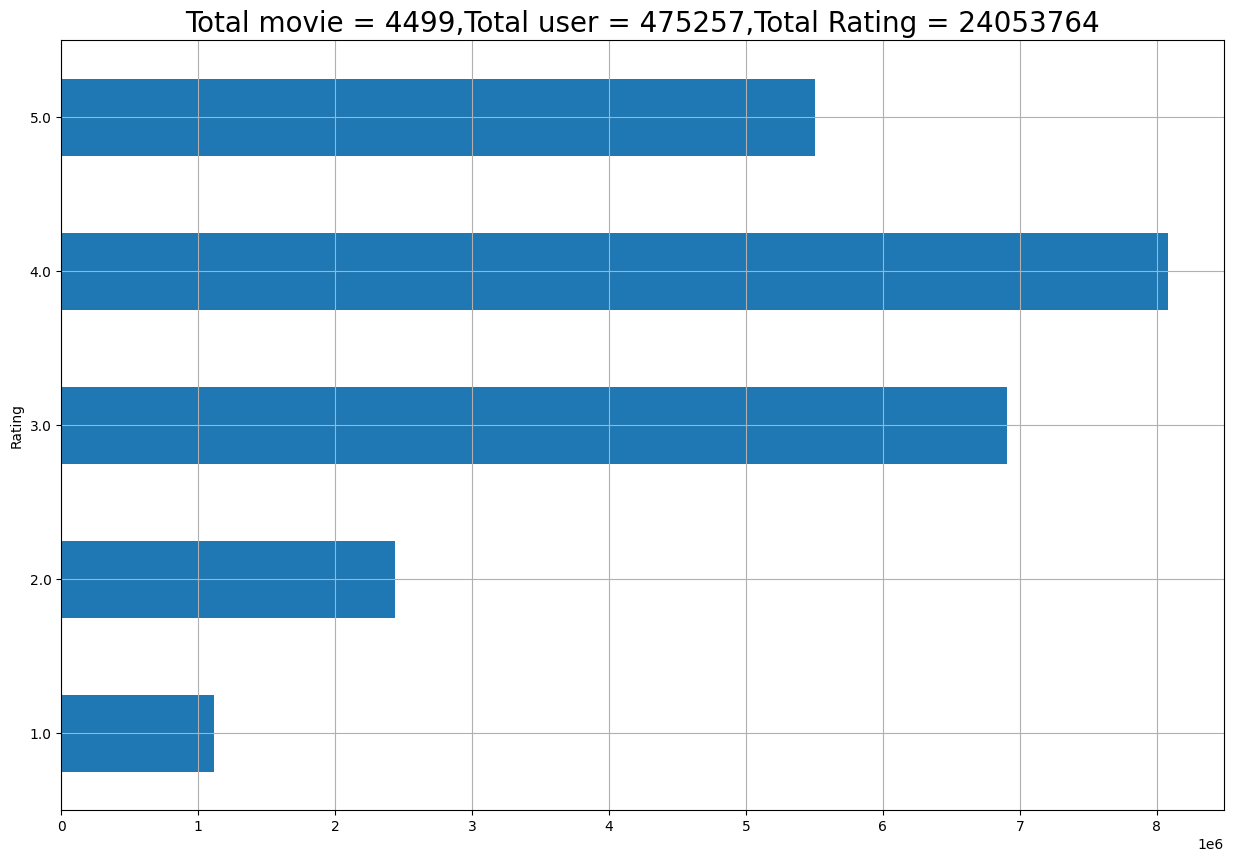

In [10]:
#To visualize
ax=stars.plot(kind='barh',legend=False,figsize=(15,10))
plt.title(f'Total movie = {movie_count},Total user = {user_count},Total Rating = {rating_count}',fontsize=20)
plt.grid(True)
plt.show()

In [11]:
#To make clear datframe to find how many movie id are there

movie_id=None
movie_np=[] #Empty list to store the movie id

#Iterate over the cust_id column
for i in netflix_dataset['Cust_Id']:
  if ':' in i:
    #Update the current movie id in column
    movie_id=int(i.replace(':',''))
    movie_np.append(movie_id)  #Adding the movie id number in the list

In [12]:
movie_np

[1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 55,
 56,
 57,
 58,
 59,
 60,
 61,
 62,
 63,
 64,
 65,
 66,
 67,
 68,
 69,
 70,
 71,
 72,
 73,
 74,
 75,
 76,
 77,
 78,
 79,
 80,
 81,
 82,
 83,
 84,
 85,
 86,
 87,
 88,
 89,
 90,
 91,
 92,
 93,
 94,
 95,
 96,
 97,
 98,
 99,
 100,
 101,
 102,
 103,
 104,
 105,
 106,
 107,
 108,
 109,
 110,
 111,
 112,
 113,
 114,
 115,
 116,
 117,
 118,
 119,
 120,
 121,
 122,
 123,
 124,
 125,
 126,
 127,
 128,
 129,
 130,
 131,
 132,
 133,
 134,
 135,
 136,
 137,
 138,
 139,
 140,
 141,
 142,
 143,
 144,
 145,
 146,
 147,
 148,
 149,
 150,
 151,
 152,
 153,
 154,
 155,
 156,
 157,
 158,
 159,
 160,
 161,
 162,
 163,
 164,
 165,
 166,
 167,
 168,
 169,
 170,
 171,
 172,
 173,
 174,
 175,
 176,
 177,
 178,
 179,
 180,
 181,
 182,
 183,
 184,
 185

In [13]:
# Create a new column 'movie_id' in netflix_dataset.
# This column will initially hold movie IDs for movie header rows and NaN for rating rows.
netflix_dataset['movie_id'] = netflix_dataset['Cust_Id'].apply(
    lambda x: int(x.replace(':', '')) if ':' in str(x) else np.nan
)

# Forward fill the 'movie_id' column to propagate the movie ID to subsequent rating entries.
netflix_dataset['movie_id'] = netflix_dataset['movie_id'].ffill()

# Now, remove the rows that were originally movie ID headers (they have NaN in the 'Rating' column).
# We also remove any rows where 'movie_id' might still be NaN after ffill to prevent conversion errors.
netflix_dataset.dropna(subset=['Rating', 'movie_id'], inplace=True)

# Convert 'Cust_Id' to numeric type, as it now only contains actual customer IDs.
netflix_dataset['Cust_Id'] = pd.to_numeric(netflix_dataset['Cust_Id'])

# Convert 'movie_id' to integer type, as it now contains valid movie IDs for all rating entries.
netflix_dataset['movie_id'] = netflix_dataset['movie_id'].astype(int)

In [14]:
netflix_dataset

,Cust_Id,Rating,movie_id
1,1488844,3.0,1
2,822109,5.0,1
3,885013,4.0,1
4,30878,4.0,1
5,823519,3.0,1
...,...,...,...
24058258,2591364,2.0,4499
24058259,1791000,2.0,4499
24058260,512536,5.0,4499
24058261,988963,3.0,4499


In [15]:
netflix_dataset=netflix_dataset[netflix_dataset['Rating'].notna()]

In [16]:
netflix_dataset

,Cust_Id,Rating,movie_id
1,1488844,3.0,1
2,822109,5.0,1
3,885013,4.0,1
4,30878,4.0,1
5,823519,3.0,1
...,...,...,...
24058258,2591364,2.0,4499
24058259,1791000,2.0,4499
24058260,512536,5.0,4499
24058261,988963,3.0,4499


In [17]:
#pre filtering
#Remove all the users who have rated less movies
#Remove all the movies which are rated less

In [18]:
#Count the ratings of the movie
movie_summary=netflix_dataset.groupby('movie_id')['Rating'].agg(['count','mean'])
movie_summary

,count,mean
movie_id,,
1,547,3.749543
2,145,3.558621
3,2012,3.641153
4,142,2.739437
5,1140,3.919298
...,...,...
4495,614,3.478827
4496,9519,3.763000
4497,714,2.715686


In [19]:
#now we will create a benchmark let consider 60 percentile
movie_benchmark=round(movie_summary['count'].quantile(0.6),0)
movie_benchmark

908.0

In [20]:
#now if any movie is having ratings less than 908 we will exclude that movie
drop_movie_list=movie_summary[movie_summary['count']<movie_benchmark].index
drop_movie_list


Index([   1,    2,    4,    7,    9,   10,   11,   12,   13,   14,
       ...
       4480, 4481, 4486, 4487, 4491, 4494, 4495, 4497, 4498, 4499],
      dtype='int64', name='movie_id', length=2699)

In [21]:
len(drop_movie_list)
#we are going to remove 2699 movies

2699

In [22]:
#counting how many users have rated hoe many movies
user_summary=netflix_dataset.groupby('Cust_Id')['Rating'].agg(['count','mean'])
user_summary

,count,mean
Cust_Id,,
6,153,3.333333
7,195,4.066667
8,21,4.000000
10,49,3.346939
25,4,3.500000
...,...,...
2649404,12,4.083333
2649409,10,4.000000
2649421,3,5.000000


In [23]:
#setting the benchmark again for 60 percentile
user_benchmark=round(user_summary['count'].quantile(0.6),0)
user_benchmark

36.0

In [24]:
#now if any user have rated less than 36 movies we will exclide that user
drop_user_list=user_summary[user_summary['count']<user_benchmark].index
drop_user_list

Index([      8,      25,      33,      83,      94,     126,     130,     133,
           142,     149,
       ...
       2649337, 2649343, 2649351, 2649376, 2649379, 2649384, 2649401, 2649404,
       2649409, 2649421],
      dtype='int64', name='Cust_Id', length=282042)

In [25]:
len(drop_user_list)

282042

In [26]:
netflix_dataset=netflix_dataset[~netflix_dataset['movie_id'].isin(drop_movie_list)]
netflix_dataset=netflix_dataset[~netflix_dataset['Cust_Id'].isin(drop_user_list)]

In [27]:
netflix_dataset

,Cust_Id,Rating,movie_id
696,712664,5.0,3
697,1331154,4.0,3
698,2632461,3.0,3
699,44937,5.0,3
700,656399,4.0,3
...,...,...,...
24056842,1055714,5.0,4496
24056843,2643029,4.0,4496
24056844,267802,4.0,4496
24056845,1559566,3.0,4496


Model Building

In [28]:
#loading the dataset
df_title=pd.read_csv('/content/drive/MyDrive/Netflix/NetflixMovieData (1).csv')

In [29]:
df_title

,1,2003,Dinosaur Planet,Unnamed: 3,Unnamed: 4,Unnamed: 5
0,2,2004.0,Isle of Man TT 2004 Review,NaN,NaN,NaN
1,3,1997.0,Character,NaN,NaN,NaN
2,4,1994.0,Paula Abdul's Get Up & Dance,NaN,NaN,NaN
3,5,2004.0,The Rise and Fall of ECW,NaN,NaN,NaN
4,6,1997.0,Sick,NaN,NaN,NaN
...,...,...,...,...,...,...
17763,17766,2002.0,Where the Wild Things Are and Other Maurice Se...,NaN,NaN,NaN
17764,17767,2004.0,Fidel Castro: American Experience,NaN,NaN,NaN
17765,17768,2000.0,Epoch,NaN,NaN,NaN
17766,17769,2003.0,The Company,NaN,NaN,NaN


In [30]:
!pip install scikit-surprise

In [31]:
pip install numpy==1.26.4

In [32]:
from surprise import Reader,SVD,Dataset
from surprise.model_selection import cross_validate

In [33]:
reader=Reader()

In [34]:
#I am doing with the top 100k rows for the quick runtime
data=Dataset.load_from_df(netflix_dataset[['Cust_Id','movie_id','Rating']][:100000],reader)

In [35]:
model=SVD()

In [36]:
#Train and evaluating the model
cross_validate(model,data,measures=['RMSE','MAE'],cv=5,verbose=True)

Evaluating RMSE, MAE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    1.0244  1.0130  1.0278  1.0172  1.0203  1.0205  0.0052  
MAE (testset)     0.8184  0.8095  0.8256  0.8136  0.8052  0.8145  0.0071  
Fit time          1.33    1.37    1.41    1.86    2.08    1.61    0.30    
Test time         0.09    0.09    0.23    0.33    0.16    0.18    0.09    


{'test_rmse': array([1.02439493, 1.01300774, 1.0277701 , 1.01721687, 1.02033834]),
 'test_mae': array([0.8184226 , 0.80949186, 0.82560508, 0.81358626, 0.80515773]),
 'fit_time': (1.3303275108337402,
  1.36814546585083,
  1.4093716144561768,
  1.85825777053833,
  2.076516628265381),
 'test_time': (0.09129142761230469,
  0.09265756607055664,
  0.23195886611938477,
  0.3266904354095459,
  0.15811443328857422)}

Recommendation

In [37]:
#Filter the data for finding a specific user to whom we are going to suggest the movie
user_rating=netflix_dataset[(netflix_dataset['Cust_Id']==2632461)]

In [38]:
user_rating

,Cust_Id,Rating,movie_id
698,2632461,3.0,3
93404,2632461,3.0,30
577895,2632461,4.0,175
1296724,2632461,4.0,290
1498351,2632461,2.0,312
1671074,2632461,3.0,329
2600549,2632461,3.0,482
3014577,2632461,4.0,571
3395020,2632461,4.0,645
3578127,2632461,2.0,692


In [39]:
len(user_rating)

53

In [40]:
#user 2632461 has rated 53 movies

In [41]:
#Making a copy of each individual customer for recommendation
user_2632461=df_title.copy()
user_2632461

,1,2003,Dinosaur Planet,Unnamed: 3,Unnamed: 4,Unnamed: 5
0,2,2004.0,Isle of Man TT 2004 Review,NaN,NaN,NaN
1,3,1997.0,Character,NaN,NaN,NaN
2,4,1994.0,Paula Abdul's Get Up & Dance,NaN,NaN,NaN
3,5,2004.0,The Rise and Fall of ECW,NaN,NaN,NaN
4,6,1997.0,Sick,NaN,NaN,NaN
...,...,...,...,...,...,...
17763,17766,2002.0,Where the Wild Things Are and Other Maurice Se...,NaN,NaN,NaN
17764,17767,2004.0,Fidel Castro: American Experience,NaN,NaN,NaN
17765,17768,2000.0,Epoch,NaN,NaN,NaN
17766,17769,2003.0,The Company,NaN,NaN,NaN


In [42]:
user_2632461 = df_title.copy()
# Explicitly set column names assuming the first three columns are movie_id, year, and title
user_2632461.columns = ['movie_id', 'year', 'title', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5']
user_2632461 = user_2632461[['movie_id', 'year', 'title']] # Keep only relevant columns
user_2632461=user_2632461[~user_2632461['movie_id'].isin(drop_movie_list)]

In [43]:
user_2632461

,movie_id,year,title
1,3,1997.0,Character
3,5,2004.0,The Rise and Fall of ECW
4,6,1997.0,Sick
6,8,2004.0,What the #$*! Do We Know!?
14,16,1996.0,Screamers
...,...,...,...
17763,17766,2002.0,Where the Wild Things Are and Other Maurice Se...
17764,17767,2004.0,Fidel Castro: American Experience
17765,17768,2000.0,Epoch
17766,17769,2003.0,The Company


In [44]:
#Predicting
user_2632461['Estimated_Ratings']=user_2632461['movie_id'].apply(lambda X:model.predict(2632461,X).est)

In [45]:
user_2632461

,movie_id,year,title,Estimated_Ratings
1,3,1997.0,Character,3.691595
3,5,2004.0,The Rise and Fall of ECW,4.219819
4,6,1997.0,Sick,2.345786
6,8,2004.0,What the #$*! Do We Know!?,2.600535
14,16,1996.0,Screamers,2.841400
...,...,...,...,...
17763,17766,2002.0,Where the Wild Things Are and Other Maurice Se...,3.454795
17764,17767,2004.0,Fidel Castro: American Experience,3.454795
17765,17768,2000.0,Epoch,3.454795
17766,17769,2003.0,The Company,3.454795


In [46]:
#Displaying the top 5 movies with the highest rating
user_2632461.sort_values('Estimated_Ratings',ascending=False,inplace=True)

In [47]:
user_2632461.head(5)

,movie_id,year,title,Estimated_Ratings
3,5,2004.0,The Rise and Fall of ECW,4.219819
1,3,1997.0,Character,3.691595
23,25,1997.0,Inspector Morse 31: Death Is Now My Neighbour,3.645865
26,28,2002.0,Lilo and Stitch,3.598174
16,18,1994.0,Immortal Beloved,3.532173
